# Bayesian Linear Regression (analytical posterior)

With a Gaussian prior $w \sim \mathcal{N}(0, \lambda^{-1} I)$ and Gaussian likelihood, the posterior is also Gaussian:

$$\Sigma = (\lambda I + \sigma^{-2} X^\top X)^{-1}, \qquad
\mu = (\lambda \sigma^2 I + X^\top X)^{-1} X^\top y$$

Predictions include uncertainty: $\sigma_0^2 = \sigma^2 + x_0^\top \Sigma x_0$.


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from house_price_predictor import (
    BayesianLinearRegression, load_housing_data, prepare_xy, train_val_split, rmse, r2_score
)


In [2]:
train, _ = load_housing_data()
X, y, feats = prepare_xy(train, features=["GrLivArea", "YearBuilt"], log_target=True)
X_tr, X_va, y_tr, y_va = train_val_split(X, y, random_state=42)

model = BayesianLinearRegression(lambda_param=0.1).fit(X_tr, y_tr)
mean, std = model.predict(X_va, return_std=True)
print("Posterior mean μ:", model.posterior_.mu)
print("Noise σ²:", model.posterior_.sigma2)
print(f"Val R²={r2_score(y_va, mean):.4f}")
print(f"Mean predictive std (log scale): {std.mean():.4f}")


Posterior mean μ: [12.01976035  0.24563097  0.18783146]
Noise σ²: 0.04892940157743093
Val R²=0.6618
Mean predictive std (log scale): 0.2215


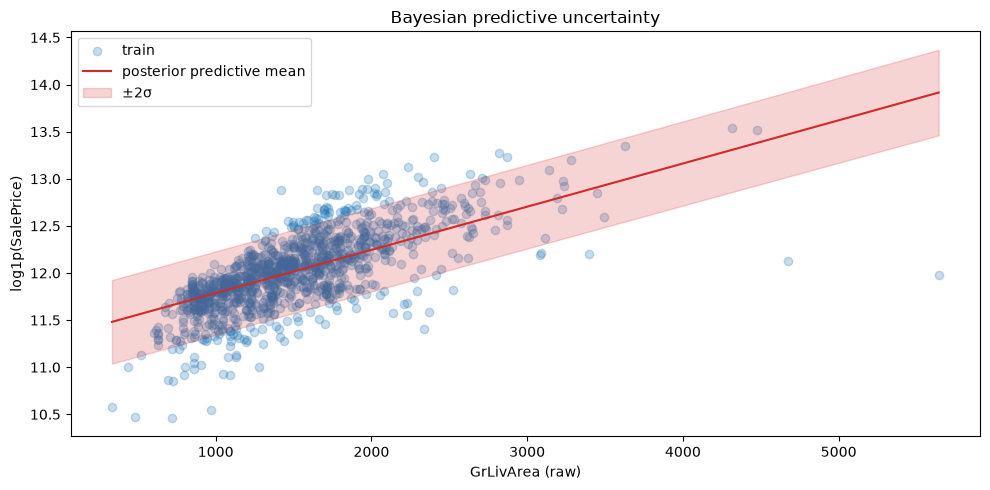

In [3]:
# Uncertainty bands along GrLivArea (YearBuilt fixed at mean)
x_grid = np.linspace(X_tr[:, 0].min(), X_tr[:, 0].max(), 100)
X_plot = np.column_stack([x_grid, np.full_like(x_grid, X_tr[:, 1].mean())])
mu, sd = model.predict(X_plot, return_std=True)

plt.figure(figsize=(10, 5))
plt.scatter(X_tr[:, 0], y_tr, alpha=0.25, label="train")
plt.plot(x_grid, mu, color="#d62828", label="posterior predictive mean")
plt.fill_between(x_grid, mu - 2 * sd, mu + 2 * sd, color="#d62828", alpha=0.2, label="±2σ")
plt.xlabel("GrLivArea (raw)"); plt.ylabel("log1p(SalePrice)")
plt.legend(); plt.title("Bayesian predictive uncertainty")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "bayesian_uncertainty.png", dpi=120)
plt.show()
